In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

df = pd.read_csv("database_gEEN.csv")

def strip_units(x):
    if isinstance(x, str):
        x = x.replace("pS", "").replace("nS", "").replace("uS", "")
        x = x.replace("mV", "").replace("ms", "")
        x = x.replace(" ", "")
        try:
            return float(x)
        except:
            return np.nan
    return x

for col in ["coh","gEEN","dt", "dt1", "dt2", "peak1", "peak2"]:
    df[col] = df[col].apply(strip_units)

numeric_cols = ["coh","gEEN","acc","dt1","dt2","dt","peak1","peak2"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()


,coh,gEIN,gEEN,gIE,acc,dt1,dt2,dt,peak1,peak2,noise_E,noise_I,seed
0,6.4,0.13,0.165,1.3,2,1750.7,NaN,1750.7,30.931057,5.828264,2.4,2.4,A01
1,6.4,0.13,0.165,1.3,1,NaN,1538.9,1538.9,8.483916,27.834914,2.4,2.4,A02
2,6.4,0.13,0.165,1.3,2,1775.8,NaN,1775.8,28.160257,7.431875,2.4,2.4,A03
3,6.4,0.13,0.165,1.3,2,1646.9,NaN,1646.9,33.118578,5.491497,2.4,2.4,A04
4,6.4,0.13,0.165,1.3,2,1778.7,NaN,1778.7,30.506251,7.847450,2.4,2.4,A05


In [2]:
# Automatically detect gEEN values
gEEN_values = sorted(df["gEEN"].dropna().unique())

# Create a perceptually uniform color palette (no overlapping colors)
import numpy as np
import matplotlib.pyplot as plt

palette = plt.cm.viridis(np.linspace(0, 1, len(gEEN_values)))
gEEN_color_map = dict(zip(gEEN_values, palette))

gEEN_color_map


{np.float64(0.15675): array([0.267004, 0.004874, 0.329415, 1.      ]),
 np.float64(0.1584): array([0.253935, 0.265254, 0.529983, 1.      ]),
 np.float64(0.16005): array([0.163625, 0.471133, 0.558148, 1.      ]),
 np.float64(0.1617): array([0.134692, 0.658636, 0.517649, 1.      ]),
 np.float64(0.16335): array([0.477504, 0.821444, 0.318195, 1.      ]),
 np.float64(0.165): array([0.993248, 0.906157, 0.143936, 1.      ])}

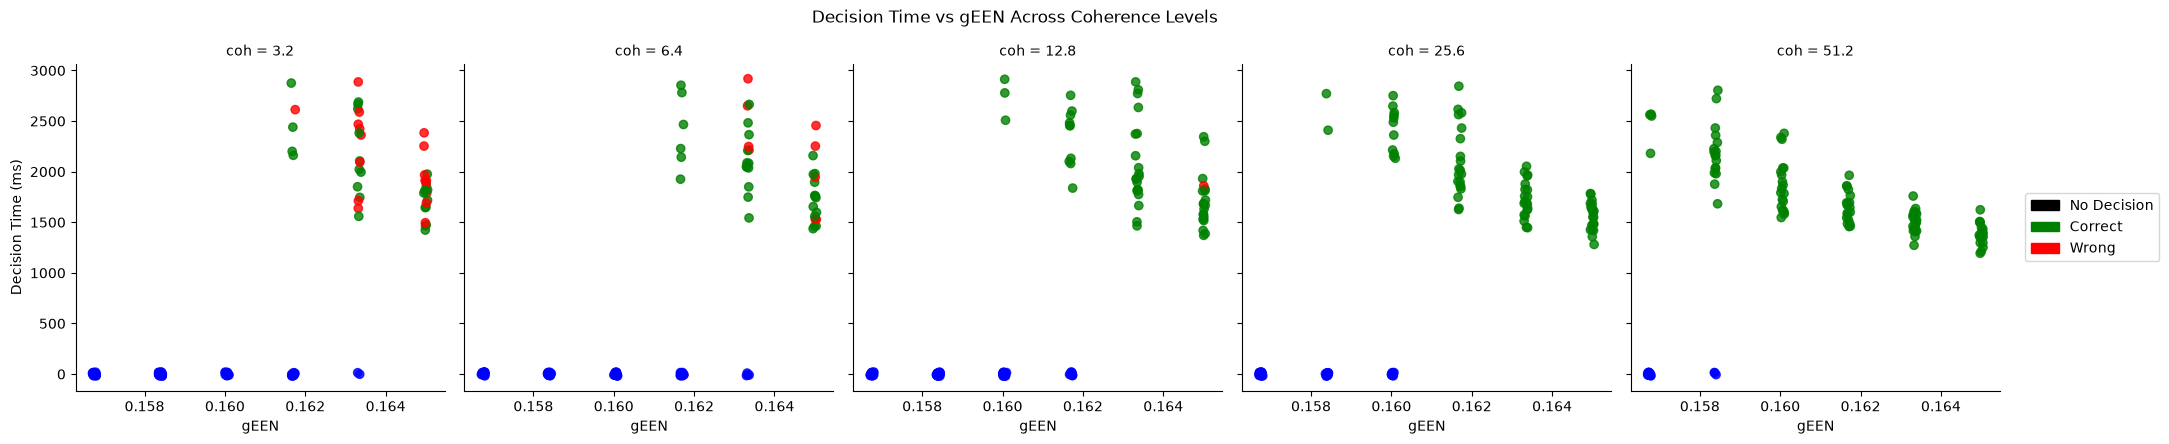

In [3]:
df_plot = df.copy()
df_plot["dt"] = df_plot["dt"].fillna(0)

color_map = {0: "blue", 1: "red", 2: "green"}
df_plot["color"] = df_plot["acc"].map(color_map)

g = sns.FacetGrid(
    df_plot,
    col="coh",
    col_wrap=5,
    height=4,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    lambda data, **kwargs: plt.scatter(
        data["gEEN"] + np.random.uniform(-0.00005, 0.00005, size=len(data)),
        data["dt"]  + np.random.uniform(-20, 20, size=len(data)),
        c=data["color"],
        alpha=0.8
    )
)

g.set_axis_labels("gEEN", "Decision Time (ms)")
g.fig.suptitle("Decision Time vs gEEN Across Coherence Levels", y=1.05)

import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color="black", label="No Decision"),
    mpatches.Patch(color="green", label="Correct"),
    mpatches.Patch(color="red", label="Wrong")
]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 0.5), loc="center left")

plt.show()


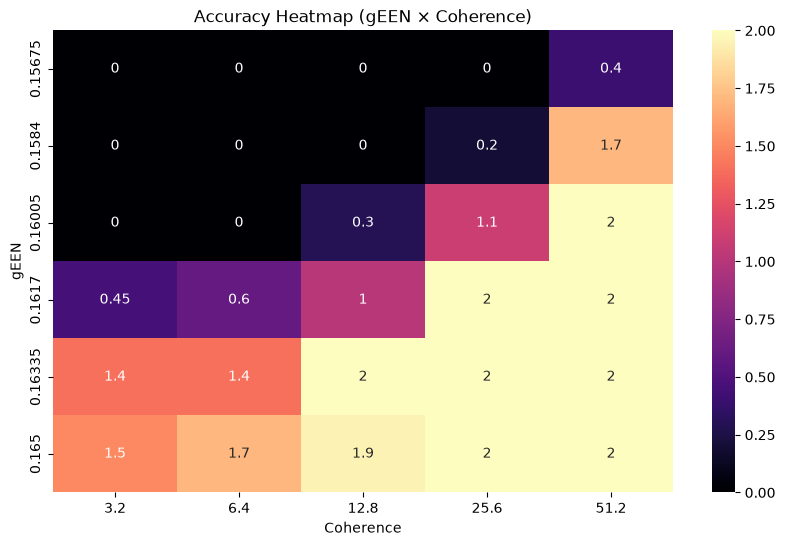

In [4]:
pivot = df.pivot_table(values="acc", index="gEEN", columns="coh", aggfunc="mean")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="magma")
plt.title("Accuracy Heatmap (gEEN × Coherence)")
plt.xlabel("Coherence")
plt.ylabel("gEEN")
plt.show()


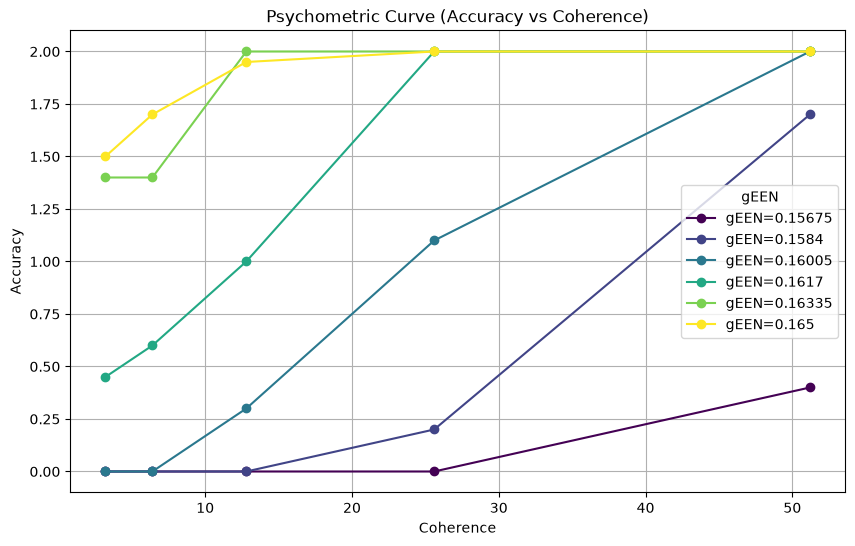

In [5]:
plt.figure(figsize=(10,6))

for g in gEEN_values:
    subset = df[df["gEEN"] == g]
    grouped = subset.groupby("coh")["acc"].mean()
    plt.plot(grouped.index, grouped.values, marker="o",
             label=f"gEEN={g}", color=gEEN_color_map[g])

plt.xlabel("Coherence")
plt.ylabel("Accuracy")
plt.title("Psychometric Curve (Accuracy vs Coherence)")
plt.legend(title="gEEN")
plt.grid(True)
plt.show()


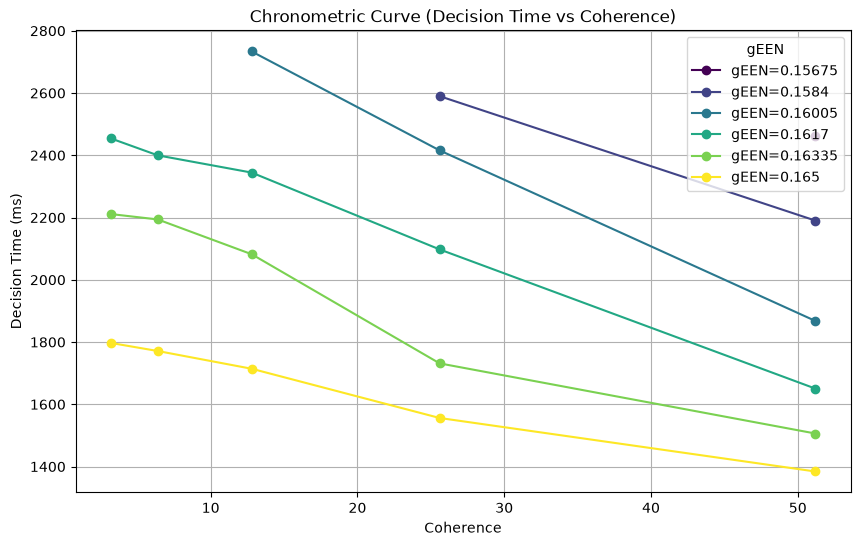

In [6]:
plt.figure(figsize=(10,6))

for g in gEEN_values:
    subset = df[df["gEEN"] == g]
    grouped = subset.groupby("coh")["dt"].mean()
    plt.plot(grouped.index, grouped.values, marker="o",
             label=f"gEEN={g}", color=gEEN_color_map[g])

plt.xlabel("Coherence")
plt.ylabel("Decision Time (ms)")
plt.title("Chronometric Curve (Decision Time vs Coherence)")
plt.legend(title="gEEN")
plt.grid(True)
plt.show()


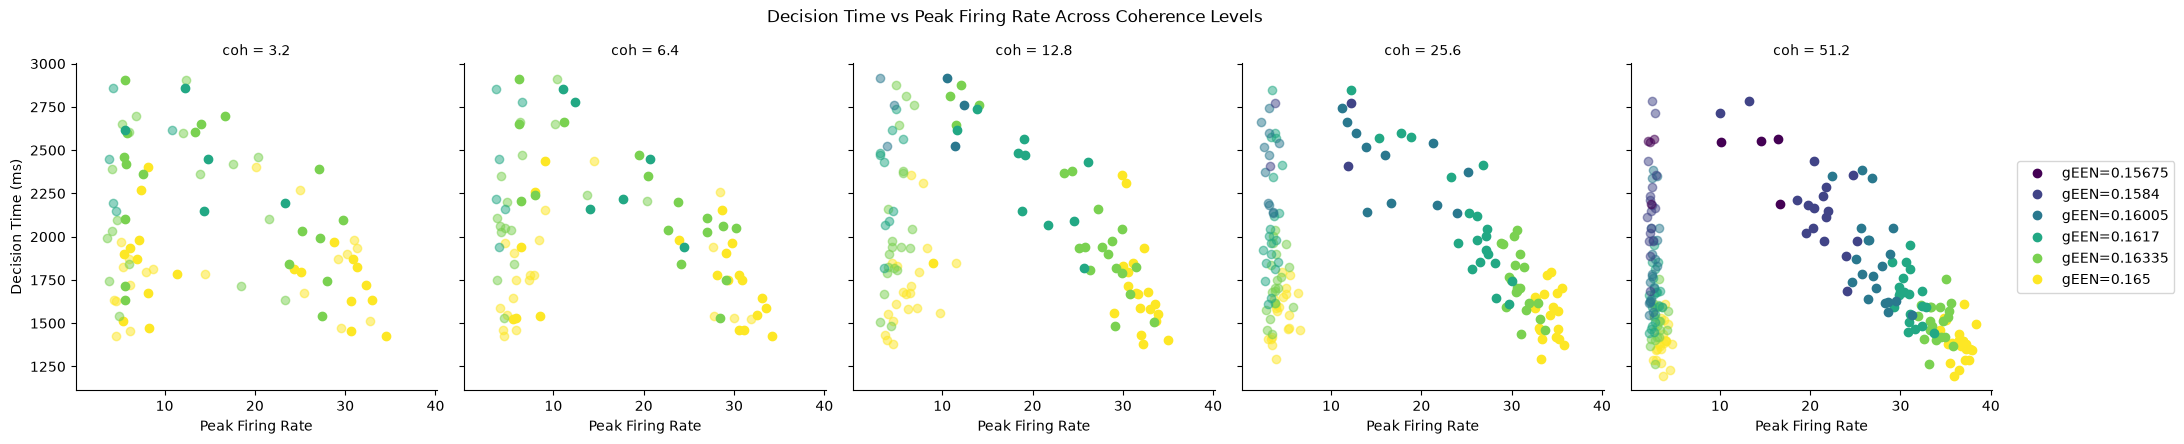

In [7]:
# Create panelled grid by coherence
g = sns.FacetGrid(
    df,
    col="coh",
    col_wrap=5,
    height=4,
    sharex=True,
    sharey=True
)

def scatter_peaks(data, color_map=None, **kwargs):
    for gEEN in data["gEEN"].unique():
        subset = data[data["gEEN"] == gEEN]

        # Stimulated population (peak1)
        plt.scatter(
            subset["peak1"],
            subset["dt"],
            color=color_map[gEEN],
            alpha=1,
            label=f"Stim Pop (gEEN={gEEN})"
        )

        # Non-stimulated population (peak2)
        plt.scatter(
            subset["peak2"],
            subset["dt"],
            color=color_map[gEEN],
            alpha=0.5,
            label=f"Non-Stim Pop (gEEN={gEEN})"
        )

# Map to FacetGrid
g.map_dataframe(scatter_peaks, color_map=gEEN_color_map)

g.set_axis_labels("Peak Firing Rate", "Decision Time (ms)")
g.fig.suptitle("Decision Time vs Peak Firing Rate Across Coherence Levels", y=1.05)

# Legend outside
handles = []
for gEEN, col in gEEN_color_map.items():
    handles.append(
        plt.Line2D([0], [0], marker='o', color=col, label=f"gEEN={gEEN}", linestyle='')
    )

plt.legend(handles=handles, bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.show()

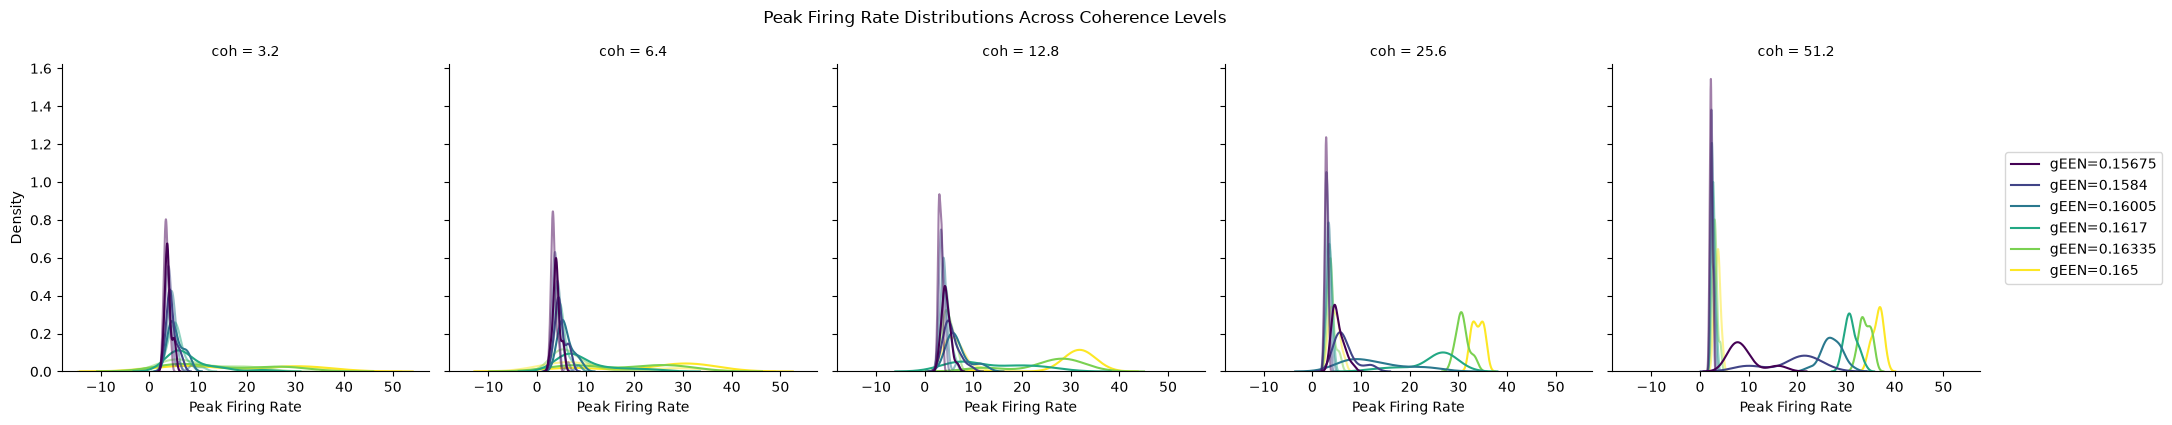

In [8]:
g = sns.FacetGrid(
    df,
    col="coh",
    col_wrap=5,
    height=4,
    sharex=True,
    sharey=True
)

def kde_peaks(data, color_map=None, **kwargs):
    for gEEN in data["gEEN"].unique():
        subset = data[data["gEEN"] == gEEN]

        sns.kdeplot(
            subset["peak1"],
            color=color_map[gEEN],
            linewidth=1.5,
            alpha=1,
            label=f"Stim Pop (gEEN={gEEN})"
        )

        sns.kdeplot(
            subset["peak2"],
            color=color_map[gEEN],
            linewidth=1.5,
            alpha=0.5,
            label=f"Non-Stim Pop (gEEN={gEEN})"
        )

g.map_dataframe(kde_peaks, color_map=gEEN_color_map)

g.set_axis_labels("Peak Firing Rate", "Density")
g.fig.suptitle("Peak Firing Rate Distributions Across Coherence Levels", y=1.05)

# Legend outside
handles = []
for gEEN, col in gEEN_color_map.items():
    handles.append(
        plt.Line2D([0], [0], color=col, label=f"gEEN={gEEN}")
    )

plt.legend(handles=handles, bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.show()

C:\Users\talha\AppData\Local\Temp\ipykernel_5152\2831875498.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


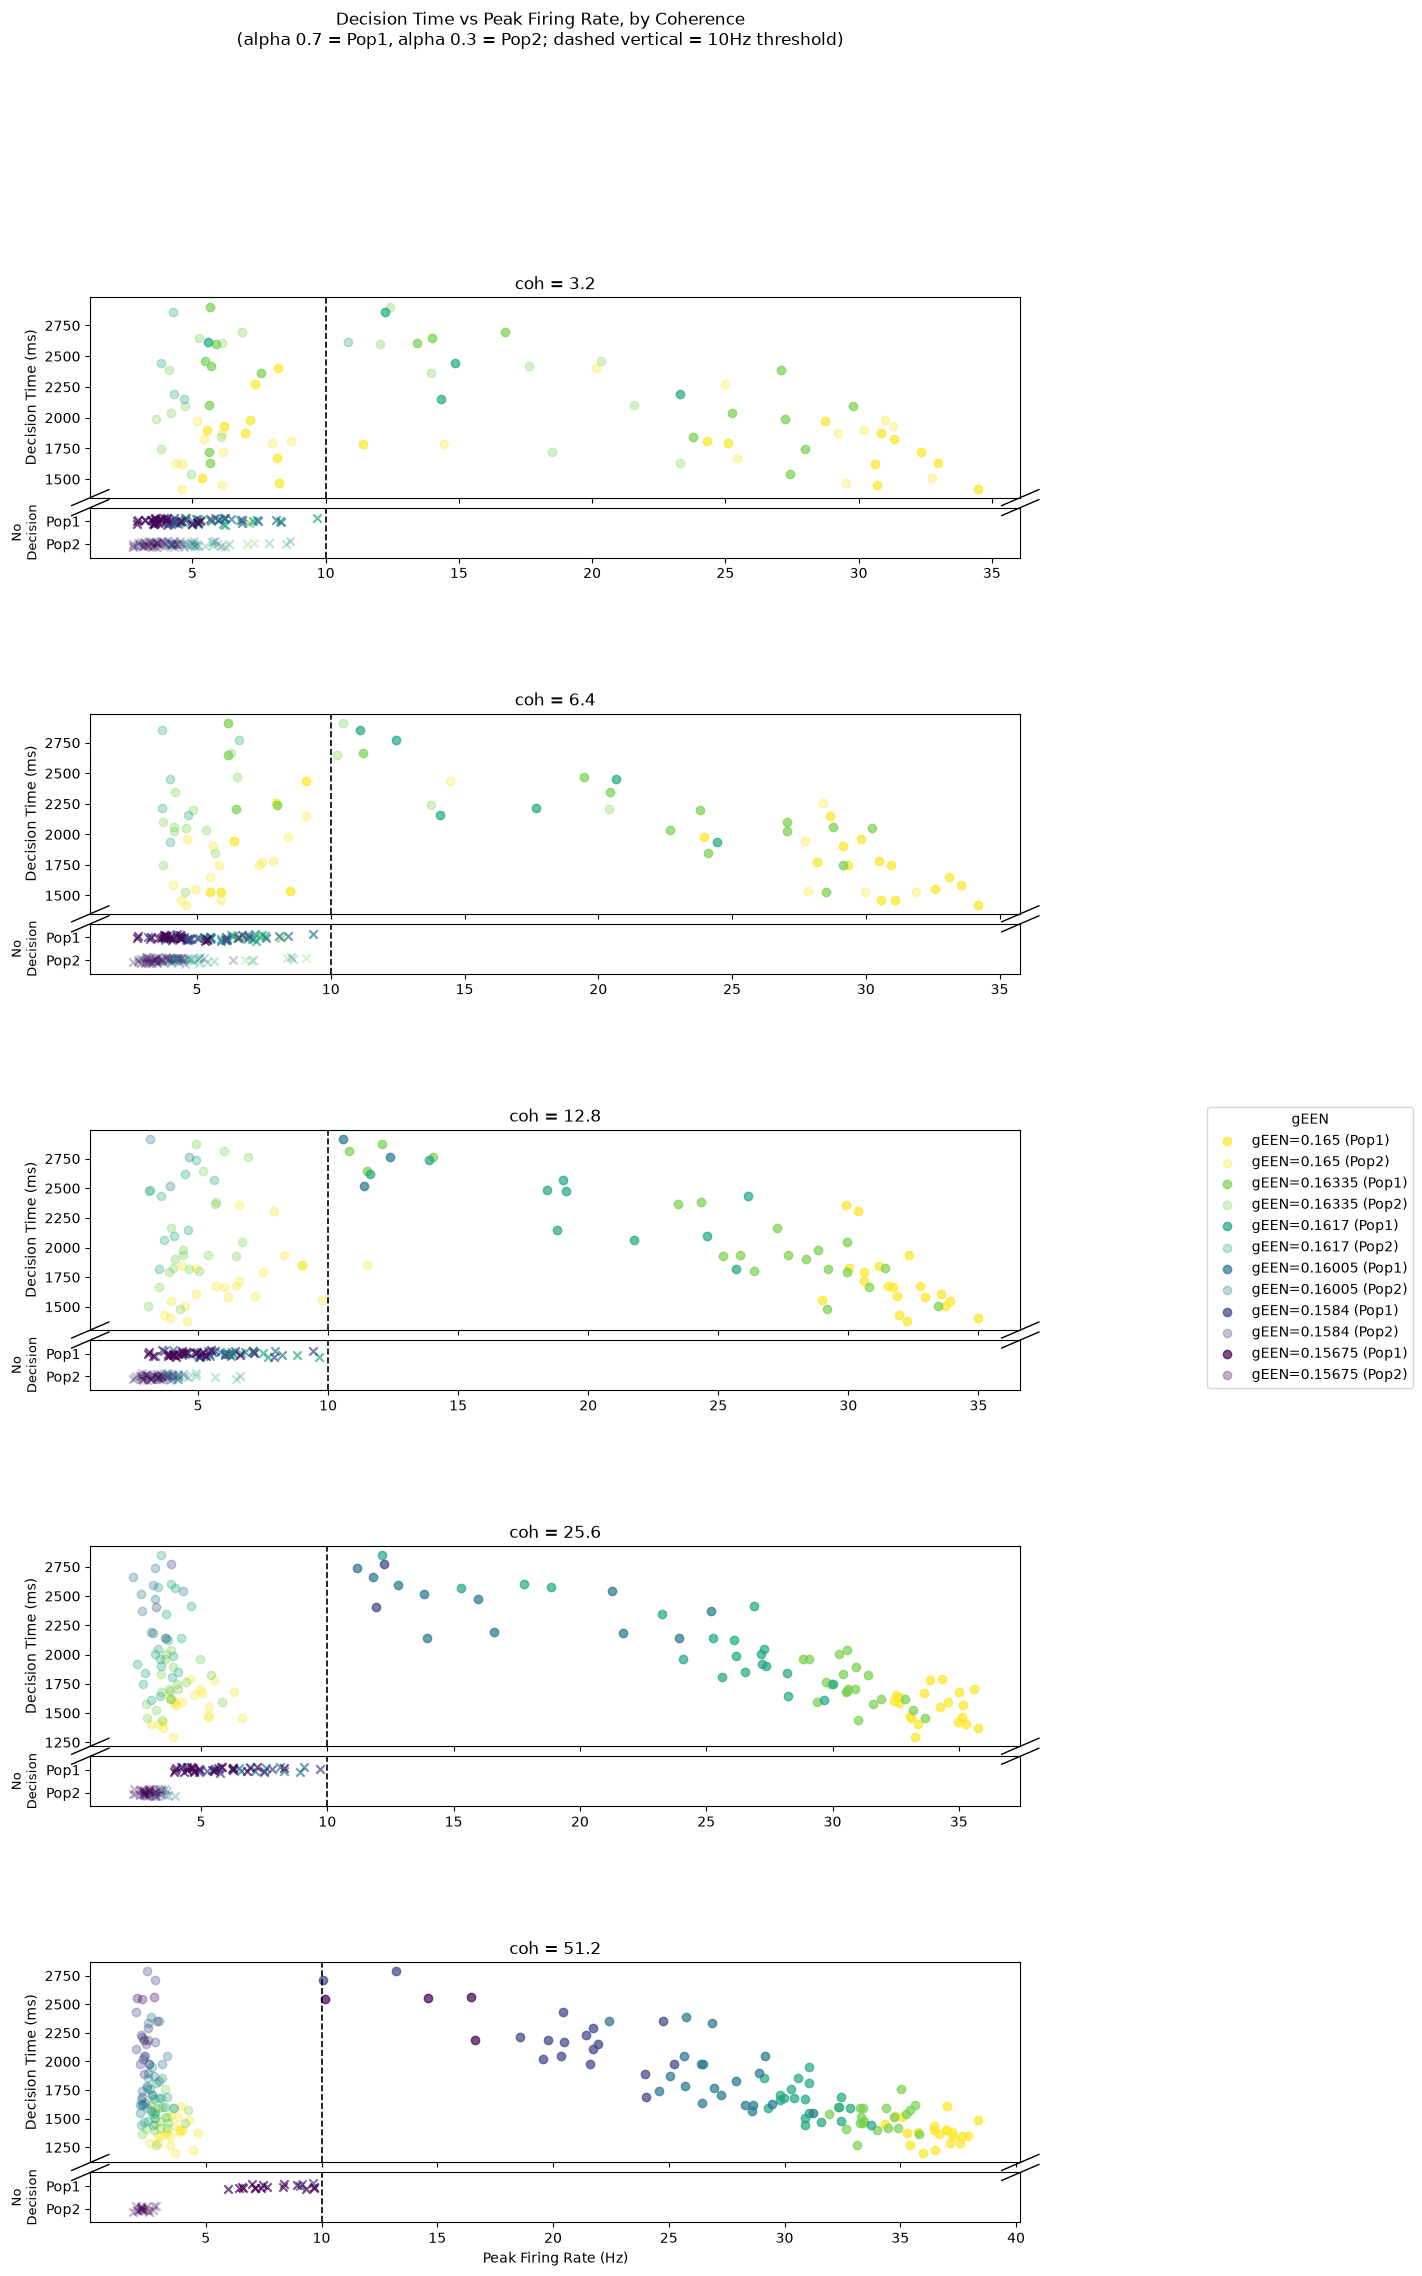

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

df_plot = df.copy()
coh_levels = sorted(df_plot["coh"].unique())
n_panels = len(coh_levels)

fig = plt.figure(figsize=(12, 5 * n_panels))
outer_gs = gridspec.GridSpec(n_panels, 1, hspace=0.6, figure=fig)

for i, coh in enumerate(coh_levels):
    # Each coherence group gets its own mini grid: big axis (dt) + thin axis (no-decision)
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer_gs[i], height_ratios=[4, 1], hspace=0.08
    )
    ax_main = fig.add_subplot(inner_gs[0])
    ax_nodec = fig.add_subplot(inner_gs[1], sharex=ax_main)

    panel_data = df_plot[df_plot["coh"] == coh]

    for gEEN in panel_data["gEEN"].unique():
        subset = panel_data[panel_data["gEEN"] == gEEN]
        color = gEEN_color_map[gEEN]

        decided = subset[subset["acc"] != 0]
        no_dec = subset[subset["acc"] == 0]

        # Main axis: real decision times
        ax_main.scatter(decided["peak1"], decided["dt"], color=color, alpha=0.7, label=f"gEEN={gEEN} (Pop1)")
        ax_main.scatter(decided["peak2"], decided["dt"], color=color, alpha=0.3, label=f"gEEN={gEEN} (Pop2)")

        # No-decision axis: two tight rows, pop1 on top, pop2 below
        jitter_pop1 = 1 + np.random.uniform(-0.15, 0.15, size=len(no_dec))
        jitter_pop2 = 0 + np.random.uniform(-0.15, 0.15, size=len(no_dec))
        ax_nodec.scatter(no_dec["peak1"], jitter_pop1, color=color, alpha=0.7, marker="x")
        ax_nodec.scatter(no_dec["peak2"], jitter_pop2, color=color, alpha=0.3, marker="x")

    ax_main.axvline(10, color="black", linestyle="--", linewidth=1.2)
    ax_nodec.axvline(10, color="black", linestyle="--", linewidth=1.2)

    ax_nodec.set_ylim(-0.6, 1.6)
    ax_nodec.set_yticks([0, 1])
    ax_nodec.set_yticklabels(["Pop2", "Pop1"])
    ax_nodec.set_ylabel("No\nDecision", fontsize=9)

    ax_main.set_ylabel("Decision Time (ms)")
    ax_main.set_title(f"coh = {coh}")
    plt.setp(ax_main.get_xticklabels(), visible=False)  # hide since it duplicates ax_nodec's

    # Break marks between the two axes to visually signal the axis discontinuity
    d = 0.02
    kwargs = dict(transform=ax_main.transAxes, color='k', clip_on=False, linewidth=1)
    ax_main.plot((-d, +d), (-d*2, +d*2), **kwargs)
    ax_main.plot((1-d, 1+d), (-d*2, +d*2), **kwargs)
    kwargs.update(transform=ax_nodec.transAxes)
    ax_nodec.plot((-d, +d), (1-d*8, 1+d*8), **kwargs)
    ax_nodec.plot((1-d, 1+d), (1-d*8, 1+d*8), **kwargs)

ax_last = fig.axes[-1]
ax_last.set_xlabel("Peak Firing Rate (Hz)")
fig.suptitle(
    "Decision Time vs Peak Firing Rate, by Coherence\n"
    "(alpha 0.7 = Pop1, alpha 0.3 = Pop2; dashed vertical = 10Hz threshold)",
    y=0.995
)

handles, labels = fig.axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), title="gEEN", bbox_to_anchor=(1.05, 0.5), loc="center left")

plt.tight_layout()
plt.show()

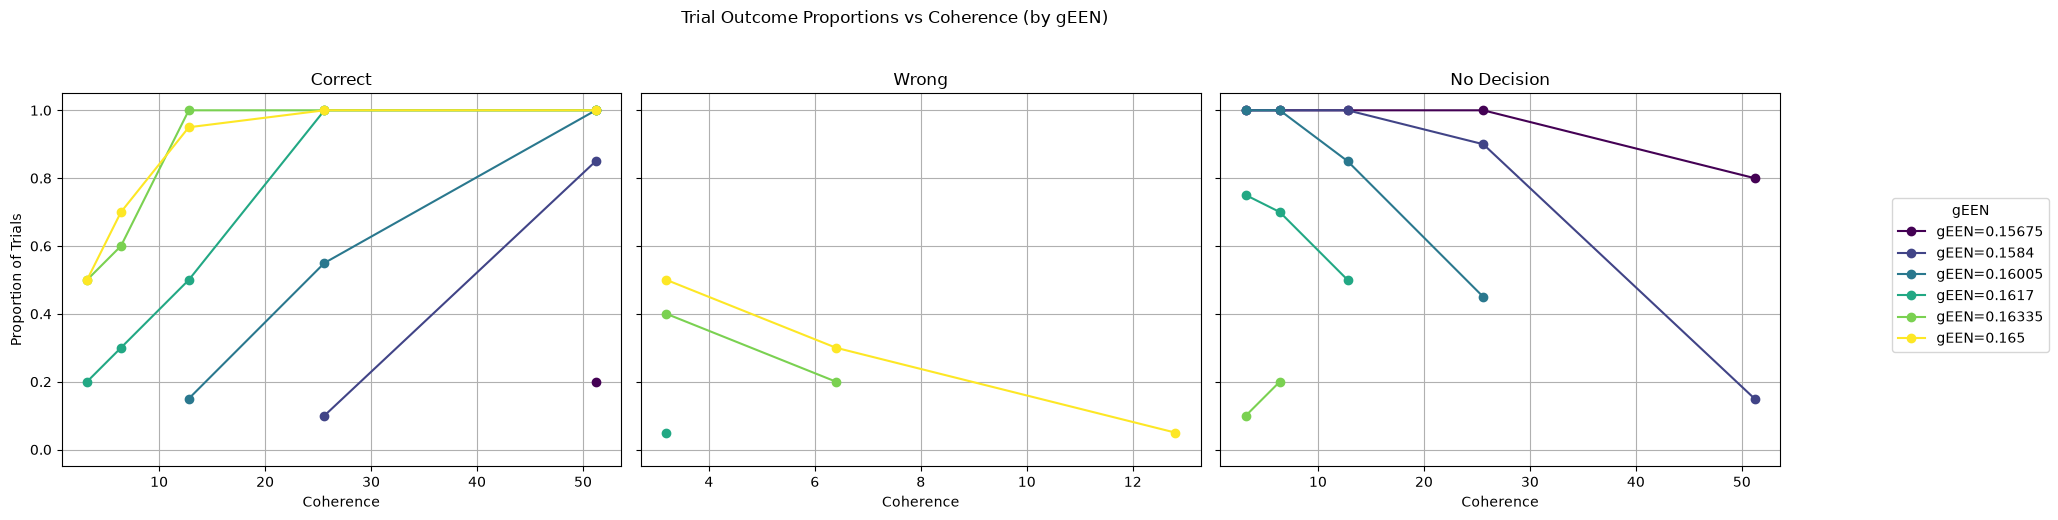

In [10]:
df_plot = df.copy()

# Compute proportion of each outcome per (coh, gEEN) cell
outcome_counts = (
    df_plot
    .groupby(["gEEN", "coh", "acc"])
    .size()
    .reset_index(name="count")
)

totals = (
    df_plot
    .groupby(["gEEN", "coh"])
    .size()
    .reset_index(name="total")
)

outcome_props = outcome_counts.merge(totals, on=["gEEN", "coh"])
outcome_props["proportion"] = outcome_props["count"] / outcome_props["total"]

# Map acc codes to readable labels
acc_labels = {0: "No Decision", 1: "Wrong", 2: "Correct"}
outcome_props["outcome"] = outcome_props["acc"].map(acc_labels)

# One panel per outcome type, x=coherence, color=gEEN — same style as your chronometric curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, outcome in zip(axes, ["Correct", "Wrong", "No Decision"]):
    subset_outcome = outcome_props[outcome_props["outcome"] == outcome]

    for gEEN in gEEN_values:
        subset = subset_outcome[subset_outcome["gEEN"] == gEEN].sort_values("coh")
        if subset.empty:
            continue
        ax.plot(
            subset["coh"], subset["proportion"],
            marker="o", label=f"gEEN={gEEN}",
            color=gEEN_color_map[gEEN]
        )

    ax.set_xlabel("Coherence")
    ax.set_title(outcome)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True)

axes[0].set_ylabel("Proportion of Trials")
fig.suptitle("Trial Outcome Proportions vs Coherence (by gEEN)", y=1.03)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="gEEN", bbox_to_anchor=(1.05, 0.5), loc="center left")

plt.tight_layout()
plt.show()